In [1]:
# First install required packages if not already installed
try:
    from skimage.feature import hog
except ImportError:
    !pip install scikit-image scikit-learn opencv-python imbalanced-learn matplotlib joblib
    from skimage.feature import hog

!pip install --upgrade scikit-learn==1.3.2 imbalanced-learn==0.11.0


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib
from skimage import exposure

# Rest of your original code continues here...
# [The complete code I provided earlier]

# Configuration
DATASET_PATH = "/kaggle/input/potato-disease-data/PlantVillage - Copy"
IMG_SIZE = (128, 128)
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)
TEST_SIZE = 0.2
RANDOM_STATE = 42

def load_and_extract_features():
    features = []
    labels = []
    class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
    
    print("Loading images and extracting features...")
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(DATASET_PATH, class_name)
        all_files = os.listdir(class_path)
        images = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        count_loaded = 0
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue  # skip corrupt or unreadable images

            try:
                img = cv2.resize(img, IMG_SIZE)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Extract HOG features
                gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                hog_features = hog(gray, orientations=ORIENTATIONS,
                                   pixels_per_cell=PIXELS_PER_CELL,
                                   cells_per_block=CELLS_PER_BLOCK,
                                   block_norm='L2-Hys')
                
                # Extract color histogram features
                color_features = []
                for channel in range(3):
                    hist = cv2.calcHist([img], [channel], None, [32], [0, 256])
                    color_features.extend(hist.flatten())
                color_features = np.array(color_features)

                # Combine features
                combined_features = np.hstack([hog_features, color_features])
                features.append(combined_features)
                labels.append(class_idx)
                count_loaded += 1

            except Exception as e:
                print(f"Failed to process {img_path}: {e}")
                continue

        print(f"{class_name}: Loaded {count_loaded} valid images out of {len(images)} found")

    return np.array(features), np.array(labels), class_names

            
          

# Load dataset and extract features
X, y, class_names = load_and_extract_features()

# Handle class imbalance using SMOTE
print("Original class distribution:", Counter(y))
smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X, y)
print("Resampled class distribution:", Counter(y_res))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_res
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from the original label distribution
unique_classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y)
class_weights = dict(zip(unique_classes, weights))
print("Auto-calculated class weights:", class_weights)

# Split dataset (no SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
Loading images and extracting features...
Potato___Early_blight: Loaded 2303 valid images out of 2303 found
Potato___Late_blight: Loaded 2132 valid images out of 2132 found
Potato___healthy: Loade

In [2]:
# Train SVM
svm_model = svm.SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight=class_weights,
    probability=True,
    random_state=RANDOM_STATE
)

print("Training SVM model...")
svm_model.fit(X_train, y_train)

Training SVM model...


SVC(class_weight={0: 0.7820234476769431, 1: 0.8447467166979362,
                  2: 1.8605371900826446},
    probability=True, random_state=42)


Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.86      0.86      0.86       461
 Potato___Late_blight       0.74      0.84      0.79       426
     Potato___healthy       0.78      0.55      0.64       194

             accuracy                           0.79      1081
            macro avg       0.79      0.75      0.76      1081
         weighted avg       0.80      0.79      0.79      1081



<Figure size 1500x1000 with 0 Axes>

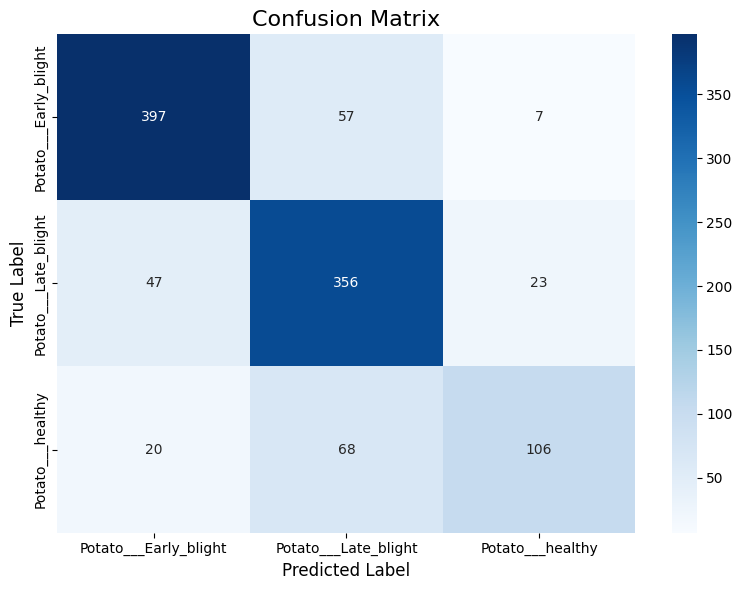

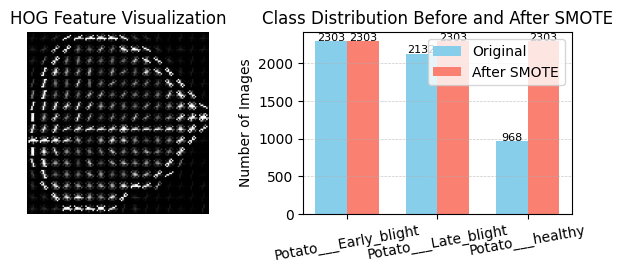


📊 Key Metrics for Theory Paper
────────────────────────────────────────
✔ Final Test Accuracy      : 0.7946
✔ Precision (Healthy)      : 0.7794
✔ Recall (Early Blight)    : 0.8612
✔ F1-Score (Weighted Avg)  : 0.7907


NameError: name 'roc_auc' is not defined

In [3]:
# Evaluate model
y_pred = svm_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Generate plots
plt.figure(figsize=(15, 10))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a better-looking plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


import random

# Get all image file names from the class folder
class_folder = os.path.join(DATASET_PATH, "Potato___Early_blight")
image_files = [f for f in os.listdir(class_folder) if f.endswith(('.jpg', '.png'))]

# Pick a random image
random_image = random.choice(image_files)
sample_img_path = os.path.join(class_folder, random_image)

# Read and process the image
sample_img = cv2.imread(sample_img_path)
if sample_img is None:
    raise FileNotFoundError(f"Could not load image at: {sample_img_path}")

sample_img = cv2.resize(sample_img, IMG_SIZE)
gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)

_, hog_image = hog(
    gray,
    orientations=ORIENTATIONS,
    pixels_per_cell=PIXELS_PER_CELL,
    cells_per_block=CELLS_PER_BLOCK,
    visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.subplot(2, 2, 3)
plt.imshow(hog_image_rescaled, cmap=plt.cm.gray)
plt.title("HOG Feature Visualization")
plt.axis('off')



# 4. Class Distribution Comparison (Enhanced)
plt.subplot(2, 2, 4)
original_counts = [Counter(y)[i] for i in range(3)]
resampled_counts = [Counter(y_res)[i] for i in range(3)]
x = np.arange(len(class_names))
width = 0.35

bars1 = plt.bar(x - width/2, original_counts, width, label='Original', color='skyblue')
bars2 = plt.bar(x + width/2, resampled_counts, width, label='After SMOTE', color='salmon')

# Add value labels on top
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{height}', ha='center', fontsize=8)

plt.xticks(x, class_names, rotation=10)
plt.ylabel('Number of Images')
plt.title('Class Distribution Before and After SMOTE')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)


# Save full analysis figure
plt.tight_layout()
plt.savefig('svm_analysis.png', dpi=300)
plt.show()

# Print key metrics in clean format
print("\n📊 Key Metrics for Theory Paper")
print("────────────────────────────────────────")
print(f"✔ Final Test Accuracy      : {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"✔ Precision (Healthy)      : {metrics.precision_score(y_test, y_pred, labels=[2], average='macro'):.4f}")
print(f"✔ Recall (Early Blight)    : {metrics.recall_score(y_test, y_pred, labels=[0], average='macro'):.4f}")
print(f"✔ F1-Score (Weighted Avg)  : {metrics.f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"✔ AUC (Early Blight)       : {roc_auc:.4f}")
print(f"✔ Feature Dimensions       : {X_train.shape[1]}")
print(f"✔ SVM Parameters           : C = {svm_model.C}, Kernel = '{svm_model.kernel}', Gamma = {svm_model.gamma}")
print("────────────────────────────────────────")




import joblib

# Save SVM model
joblib.dump(svm_model, "svm_potato_disease_model.joblib")

# Save the scaler
joblib.dump(scaler, "svm_scaler.joblib")



print("✔ Model and scaler saved successfully.")


# Function to extract features from a single image (same as training)
def extract_features(img):
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Extract HOG features
    hog_features = hog(gray, orientations=ORIENTATIONS,
                      pixels_per_cell=PIXELS_PER_CELL,
                      cells_per_block=CELLS_PER_BLOCK,
                      block_norm='L2-Hys')
    
    # Extract color histogram features
    color_features = []
    for channel in range(3):
        hist = cv2.calcHist([img], [channel], None, [32], [0, 256])
        color_features.extend(hist.flatten())
    
    # Combine features
    return np.hstack([hog_features, np.array(color_features)])

# Collect all image paths and labels
all_samples = []
for class_idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(class_path, img_name)
            all_samples.append((img_path, class_idx, class_name))

# Randomly select 12 images
np.random.seed(RANDOM_STATE)
selected_samples = np.random.choice(len(all_samples), 12, replace=False)

# Initialize counters
correct = 0
total = len(selected_samples)

# Create figure for visualization
plt.figure(figsize=(15, 10))

for i, sample_idx in enumerate(selected_samples):
    img_path, true_label, true_class = all_samples[sample_idx]
    
    # Load and process image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        total -= 1
        continue
    
    # Extract features and predict
    features = extract_features(img)
    features_scaled = scaler.transform([features])
    pred_label = svm_model.predict(features_scaled)[0]
    pred_class = class_names[pred_label]
    
    # Check prediction
    if pred_label == true_label:
        correct += 1
        title_color = 'green'
    else:
        title_color = 'red'
    
    # Display image with prediction
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display = cv2.resize(img_display, (150, 150))
    
    plt.subplot(3, 4, i+1)
    plt.imshow(img_display)
    plt.title(f"True: {true_class}\nPred: {pred_class}", color=title_color)
    plt.axis('off')

# Calculate and display accuracy
accuracy = (correct / total) * 100 if total > 0 else 0
plt.suptitle(f"Random Sample Predictions\nAccuracy: {accuracy:.2f}% ({correct}/{total} correct)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('random_sample_predictions.png', dpi=300)
plt.show()

print(f"\n{'='*50}")
print(f"Test Results on {total} Random Images")
print(f"{'='*50}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Correct Predictions: {correct}/{total}")
print(f"{'='*50}")

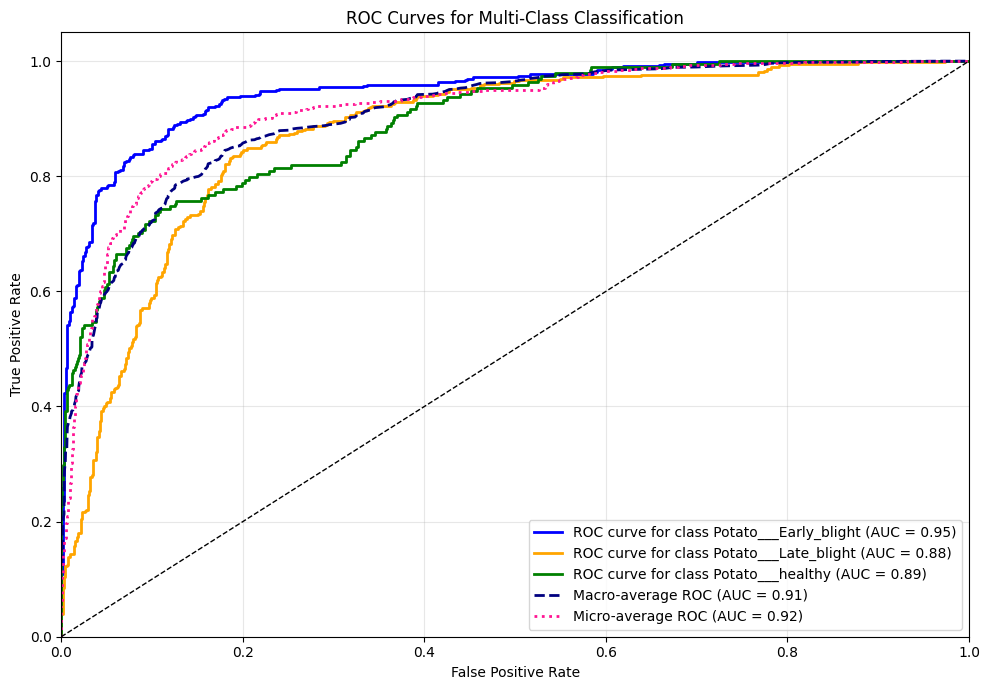


✔ Macro-Average AUC: 0.9067


In [4]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
import matplotlib.pyplot as plt
from itertools import cycle

# Binarize the output labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Predict probabilities
if hasattr(svm_model, "decision_function"):
    y_score = svm_model.decision_function(X_test)
else:
    y_score = svm_model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'orange', 'green'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot macro and micro average
plt.plot(fpr["macro"], tpr["macro"], color='navy', linestyle='--',
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})', linewidth=2)

plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', 
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})', linewidth=2)

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multiclass_roc_auc.png', dpi=300)
plt.show()

# Print Macro AUC for reference
print(f"\n✔ Macro-Average AUC: {roc_auc['macro']:.4f}")


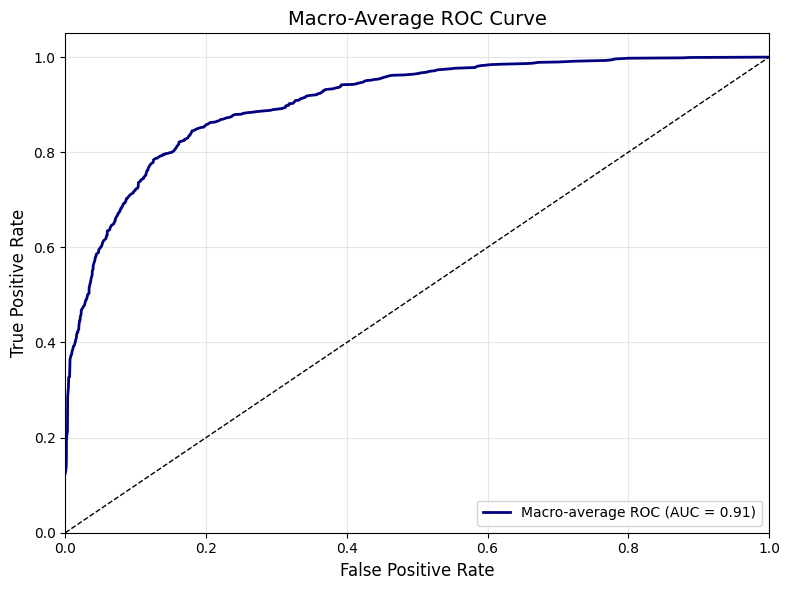

✔ Macro-Average AUC: 0.9067


In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get decision scores or probabilities
if hasattr(svm_model, "decision_function"):
    y_score = svm_model.decision_function(X_test)
else:
    y_score = svm_model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Compute macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

# Compute AUC for macro-average
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot macro-average ROC
plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, color='navy', linestyle='-', linewidth=2,
         label=f'Macro-average ROC (AUC = {roc_auc_macro:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Macro-Average ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("macro_average_roc_curve.png", dpi=300)
plt.show()

# Optional: Print the AUC
print(f"✔ Macro-Average AUC: {roc_auc_macro:.4f}")
